
# Introduction to Selenium



### Learning Objectives

- Introduce Selenium as a solution, and implement a scraper using selenium

-----
\
*Last Checked and Updated 4-7-2026*
\
*Tested on python version 3.12.10*


### What is Selenium?
---

* Selenium is a web automation framework that can be used to automate website testing. 
* Selenium starts a web-browser, it can do any task you would normally do on the web (ex: It allows us to render JavaScript just as a human-navigated browser would)

### Install Selenium

Students will need to install Selenium using one of the following:
- **Anaconda:** `conda install -c conda-forge selenium`
- **pip:** `pip install selenium`



In [2]:
# %pip install selenium

In [6]:
# if not installed before, install it
# %pip install httpx

Load necessary libraries.

In [9]:
import re #Regular expression
import requests
import httpx   # you can use either httpx or requests libraries 
import pandas as pd
from bs4 import BeautifulSoup
from time import sleep
from selenium import webdriver
from datetime import date
from datetime import timedelta
from selenium.common.exceptions import NoSuchElementException
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.webdriver.common.keys import Keys
from io import StringIO


## Web scraping steps :

#### Step 1 : Download Html page 
#### Step 2 : Parsing data (BeautifulSoup)(Selenium)(xpath)
#### Step 3 : Save data in dataframe

## 1. Why to use Selenium?
---

<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/4/43/Resy_logo.svg/500px-Resy_logo.svg.png" style="float: left; margin: 20px; height: 55px">
<br>

## Let's Scrape (Resy) Website

<br>

[Resy](https://resy.com/cities/washington-dc?date=2026-07-04&seats=2) is an online table booking in restaurants. Let's scrape their site to get how many times each restaurant has booked.

let's start by explore the structure of the page

### `httpx.get` or `requests.get` to get the html page

In [10]:
## Step 1 : Download Html page 
url="https://resy.com/cities/washington-dc?date=2026-07-04&seats=2"
html_page = requests.get(url)
html_page.status_code


# or you can use requests.get
# html_page = httpx.get(url)
# html_page.status_code

200

In [11]:
# check what is html looks like
# html_page.text   

In [12]:
# step 2 : parsing

In [13]:
soup = BeautifulSoup(html_page.text ,'html')

In [14]:
# Well, we want to know today's booking!

In [15]:
items= soup.find_all('div', attrs={'role': 'option'}) # Nothing is there!


In [16]:
len(items)

0

- Nothing is there!
- The reason for that is the page is loading JavaScript when you open the browser. 
- Loading JavaScript can't be done using `httpx` or `requests`


### 1.1 Example on using Selenium 

> [Official Selenium site](https://www.selenium.dev/) 

In [17]:
## Step 1 : Open webdriver browser and Download Html page using webdriver 

In [19]:
#a. create browser obj
driver = webdriver.Chrome()

#b. specify the url
url = 'https://www.coursera.org/search?query=machine%20learning&page=1&sortBy=BEST_MATCH&index=prod_all_products_term_optimization'

#c. make the webdriver get the page at the url
driver.get(url)

#d. Give some delay execution for a given number of seconds
# to allow the page to be fully loaded
sleep(5) 


In [20]:
# step 2 : parsing

In [21]:
#e. Provide BeautifulSoup with the driver.page_source of the page opened using selenium
#   save the result into a variable with a name you choose
soup = BeautifulSoup(driver.page_source,'html.parser')  #'html.parser')

In [22]:
#e. Close the driver if you are done. This will close the poped out browser
# if you need to download more pages, don't close it for now
# driver.close() 

In [23]:
# make sure there is a data in the soup variable
# soup

In [24]:
myitems =soup.find_all('li',class_="cds-9 css-0 cds-11 cds-grid-item cds-56 cds-64 cds-76 cds-89")


In [25]:
len(myitems)

12

In [26]:
# myitems[0]

In [27]:
myitems[0].find("h3",class_="cds-CommonCard-title css-6ecy9b").text


'Machine Learning'

In [28]:
# create an empty list to save all the coursera course titles
course_title=[]

# loop through the myitems to find the titles and save 
# them in course_title list
for i in myitems:
    course_title.append(i.find("h3",class_="cds-CommonCard-title css-6ecy9b").text)
    

# display the list we got    
course_title

['Machine Learning',
 'Machine Learning with Python',
 'IBM Machine Learning',
 'Mathematics for Machine Learning',
 'Machine Learning',
 'Supervised Machine Learning: Regression and Classification',
 'IBM Introduction to Machine Learning',
 'Python for Data Science, AI & Development',
 'Deep Learning',
 'Introduction to Artificial Intelligence (AI)',
 'The Nuts and Bolts of Machine Learning',
 'Mathematics for Machine Learning and Data Science']

### 1.2 Another example on using Selenium
- On the first part when we covered an introduction to web scraping, we used BeatifulSoup to try to scrape Amazon but we were not able to see all the items in the web page (items that are sponsored). 
- The reason for that is that Amazon site is using JavaScript on loading some of the items. 
- Let's try to use Selenium to see if we are able to see all the items

#### Using selenium webdriver to get all items

In [29]:
#a. create browser obj
driver = webdriver.Chrome()

#b. specify the url

url="https://www.amazon.sa/-/en/s?k=Computer+Tablets&i=computers&rh=n%3A16966433031&language=en&c=ts&qid=1706531941&ts_id=16966433031&ref=sr_pg_1"

#c. make the webdriver get the page at the url
driver.get(url)

#d. Give some delay execution for a given number of seconds
# to allow the page to be fully loaded
sleep(5) 


In [30]:
#e. Provide BeautifulSoup with the driver.page_source of the page opened using selenium
#   save the result into a variable with a name you choose
soup3 = BeautifulSoup(driver.page_source, 'html.parser')  #<shift + tab>

In [31]:
#f. Close the driver if you are done. This will close the poped out browser
# if you need to download more pages, don't close it for now
# driver.close() 

In [32]:
soup3.title


<title>Amazon.sa : Computer Tablets</title>

In [33]:
# bigger box selection
amazon=soup3.find_all('div', class_="a-section a-spacing-small puis-padding-left-small puis-padding-right-small")

len(amazon)

33

- We were able to see 24 items only using BeatifulSoup but now we can see all 33 items

## 2. Web Automation and Searching using Selenium 
---

### 2.1 Using `driver.find_element()` to search for elements inside a page :
The attributes available for `By` are used to locate elements on a page. These are the attributes available for `By`:

- find_element(By.TAG_NAME, "tag name")
- find_element(By.CLASS_NAME, "class name")
- find_element(By.ID, "id")
- find_element(By.NAME, "name")
- find_element(By.LINK_TEXT, "link text")
- find_element(By.PARTIAL_LINK_TEXT, "partial link text")
- find_element(By.XPATH, "xpath")
- find_element(By.CSS_SELECTOR, "css selector")


> Example: 
``` python
<html>
 <body>
   <h1>Welcome</h1>
   <p class="content" id="loginForm" >Site content goes here.</p>
   <li name="newitem" type="text" />
   <a href="continue.html">Continue</a>
 </body>
</html>


driver.find_element(By.TAG_NAME, 'h1')
driver.find_element(By.CLASS_NAME, 'content')
driver.find_element(By.ID, 'loginForm')
driver.find_element(By.NAME, 'newitem')
driver.find_element(By.LINK_TEXT, 'Continue')
driver.find_element(By.PARTIAL_LINK_TEXT, 'Conti')
driver.find_element(By.XPATH, "specify the xpath")
driver.find_element(By.CSS_SELECTOR,"specify css selector")
```

- More documentation on the following link:
 https://selenium-python.readthedocs.io/locating-elements.html

### 2.2 Some automation tools with webdriver

- `.clear()` to clear a text input in the web page
- `.send_keys()` to send a string to the text input in the web page
- `.send_keys(Keys.ENTER)` to press Enter key
- `.click()` to click a button in the web page



### 2.3 Example using web automation

Let's do automated Search for `apple` phones in [Amazon Saudi](http://www.amazon.sa/)


.
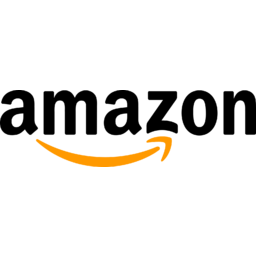



In [32]:
# create browser obj
driver = webdriver.Chrome() 

#b. specify the url
url='https://www.amazon.sa/'

#c. make the webdriver get the page at the url
driver.get(url)

#d. Sleep for few seconds
sleep(5) # 


In [35]:
# access search box using By.ID
driver.find_element(By.ID, 'twotabsearchtextbox').clear()
# Clear the box

# send keys 'apple'
driver.find_element(By.ID, 'twotabsearchtextbox').send_keys('apple')
driver.find_element(By.ID, 'twotabsearchtextbox').send_keys(Keys.ENTER)
# access of search button using By.ID
driver.find_element(By.ID,'nav-search-submit-button').click()
# click the button



# give it some time to load the searched page
sleep(2)  
# you can also use driver.sleep(2) using selenium

#   Provide BeautifulSoup with the driver.page_source of the page opened using selenium
#   save the result into a variable with a name you choose
# soup4 = BeautifulSoup(driver.page_source, 'html.parser')

# close the page if you are done
# driver.close()

> Do the necessary Beautiful Soup now to get the items out of the web page

<div class="alert alert-info">
    <h4 class="alert-heading">Quick Exercise:</h4>
     </div>

#### Q1. 
- go to this site https://www.bna.bh/en/ and open it using selenium webdriver
- at the search text, search for `alba`
- get the result of the search
- Hint: you may need to send an `Enter` key

In [41]:
driver = webdriver.Chrome() 

#b. specify the url
url='https://www.bna.bh/en/'  #Specify the url link here

#c. make the webdriver get the page at the url
driver.get(url)
sleep(5)


In [51]:
# Your code here please

# access search box using By.ID
driver.find_element(By.ID, 'header1_txtSearch').click()
# # Clear the box
driver.find_element(By.ID, 'header1_txtSearch').clear()
driver.find_element(By.ID, 'header1_txtSearch').send_keys('alba')
driver.find_element(By.ID, 'header1_txtSearch').send_keys(Keys.ENTER)


# give it some time to load the searched page
sleep(2)  


#### Q2. 
- go to this site https://www.sephora.me/bh-en/shop/fragrance/C301 and open it using selenium webdriver
- at the search text, search for `ARMANI`
- get the result of the search
- Hint: You can use By.TAG_NAME
- Hint: you may need to send an `Enter` key 

In [55]:
driver = webdriver.Chrome() 

#b. specify the url
url='https://www.sephora.me/' #Specify the url link here

#c. make the webdriver get the page at the url
driver.get(url)
sleep(5)


In [66]:
# Your code here please
# Your code here please

driver.find_element(By.TAG_NAME, 'input').click()# # # Clear the box
driver.find_element(By.TAG_NAME, 'input').clear()
driver.find_element(By.TAG_NAME, 'input').send_keys('ARMANI')
driver.find_element(By.TAG_NAME, 'input').send_keys(Keys.ENTER)


# give it some time to load the searched page
sleep(2)  


<div class="alert alert-success" role="alert">
  <h4 class="alert-heading">Well done!</h4>
  You have successfully completed your exercise.
</div>


### 2.4  Scroll down to the bottom of the web page with Selenium

--- 
- Some web pages does not open completely unless you scroll down to the bottom and then it will load the rest of the page. 
- Take a look at google play site
https://play.google.com/store/games?device=phone to get the idea
> Below is the way to scroll to the bottom of the web page

#### 2.4.1 Function to do the scroll down of a page

> Run this function once and call it whenever you need to scroll down of a page

In [68]:
def scroll(driver):
#**********************************************************************************************************#
################################## Start of the scroll page code ###########################################

    # # Get scroll height
    last_height = driver.execute_script("return document.body.scrollHeight")
#     print ('first last height',last_height)  # print last height for debugging purposes
    while True:
        # Scroll down to bottom
        driver.execute_script("window.scrollTo(0, document.body.scrollHeight-1000);") 
        # Husain note: the "-1000" was added by me because some sites like souq.com does not show the next button if you scroll to the end...
        # of the page. You car remove if it works for you without it.

        # Wait to scroll the page down
        sleep(5)

        # Calculate new scroll height and compare with last scroll height
        new_height = driver.execute_script("return document.body.scrollHeight")

#         print ('new height',new_height)  # print new height after scroll for debugging purposes

        if new_height == last_height:
            break
        last_height = new_height

    # ################################## End of the scroll page code #############################################
    # #**********************************************************************************************************#

#### 2.4.2 Example on using the `scroll` function

> Let's do it on google play site


In [69]:
# open browser
driver = webdriver.Chrome()
url="https://play.google.com/store/games?device=phone"
driver.get(url)

sleep(5) # sleep for few seconds to make sure that the initial page is opened


# call the scroll function that we created earlier to scroll to the end of the page
scroll(driver)

# do Beatiful soup
soup=BeautifulSoup(driver.page_source,'html.parser')


# Since the page shows "Show More", we can click it using either of:
# driver.find_element(By.CLASS_NAME,"CwaK9").click()
# or
# driver.find_element(By.CSS_SELECTOR, '#yDmH0d > c-wiz.SSPGKf.glB9Ve > div > div > div.N4FjMb.Z97G4e > c-wiz > div > c-wiz > div > div').click()

# driver.close() # close the opened browser page after done.



## 3. Going to the `Next Pages` in the browser

> Below, I demonstrated three methods. You can find other methods too.

--- 


In [2]:
# let's open ikea site using selenium
# https://www.ikea.com/sa/en/cat/chairs-fu002/?page=1


url="https://www.ikea.com/sa/en/cat/dining-furniture-700417/"
driver = webdriver.Chrome()
driver.get(url)

In [3]:
# You can get the current url that is used by the driver
driver.current_url

'https://www.ikea.com/sa/en/cat/dining-furniture-700417/'

### 3.1 Method 1: If the next pages has ordered numbering, you can use `format` to go through pages 


In [7]:
# In our sample site, the page numbers are in sequence, so, you can use this option too 

# Example:
for i in range(1,6):
    driver.get(f"https://www.ikea.com/sa/en/cat/dining-furniture-700417/?page={i}")
    print(driver.current_url)
    
# or 
# for i in range(1,6):
#     driver.get("https://www.ikea.com/sa/en/cat/dining-furniture-700417/?page={}".format(i))

https://www.ikea.com/sa/en/cat/dining-furniture-700417/
https://www.ikea.com/sa/en/cat/dining-furniture-700417/?page=2
https://www.ikea.com/sa/en/cat/dining-furniture-700417/?page=3
https://www.ikea.com/sa/en/cat/dining-furniture-700417/?page=4
https://www.ikea.com/sa/en/cat/dining-furniture-700417/?page=5


### 3.2 Method 2: using Beautifulsoup to locate next page! easy!


In [5]:
# Step1: Locate the next page tag from the page
# <a href="https://www.ikea.com/sa/en/cat/kitchen-doors-drawer-fronts-700293/?page=2#products-page-2" aria-label="Show more products" class="plp-btn plp-btn--small plp-btn--secondary"><span class="plp-btn__inner"><span class="plp-btn__label">Show more</span></span></a>
# Step2: use find to get the next page link

# Note: same class name will show two href result, one for previous page and second for next page. Check following code to make it clear
# soup.find_all('a',class_="plp-btn plp-btn--small plp-btn--secondary")


# To use Beautiulsoup for page parsing after you opened it using selenium

soup = BeautifulSoup(driver.page_source,'html.parser')

next_page=soup.find_all('a',class_="plp-btn plp-btn--small plp-btn--secondary")[1]['href']

next_page


'https://www.ikea.com/sa/en/cat/dining-furniture-700417/?page=2#products-page-2'

In [6]:
driver.get(next_page)

print(driver.current_url)

https://www.ikea.com/sa/en/cat/dining-furniture-700417/?page=2


### 3.3 Method 3: using selenium click() to click next page button


In [41]:
# Step1:
# While you are on the page, right click the mouse and choose inspect

# Step2:
# while you are in the inspect page, select the element of "next" button

# Step3:
# right click on the element from the inspect page and select "copy"

# step4:
# while you are selecting copy, choose either "copy selector" or "copy XPath"



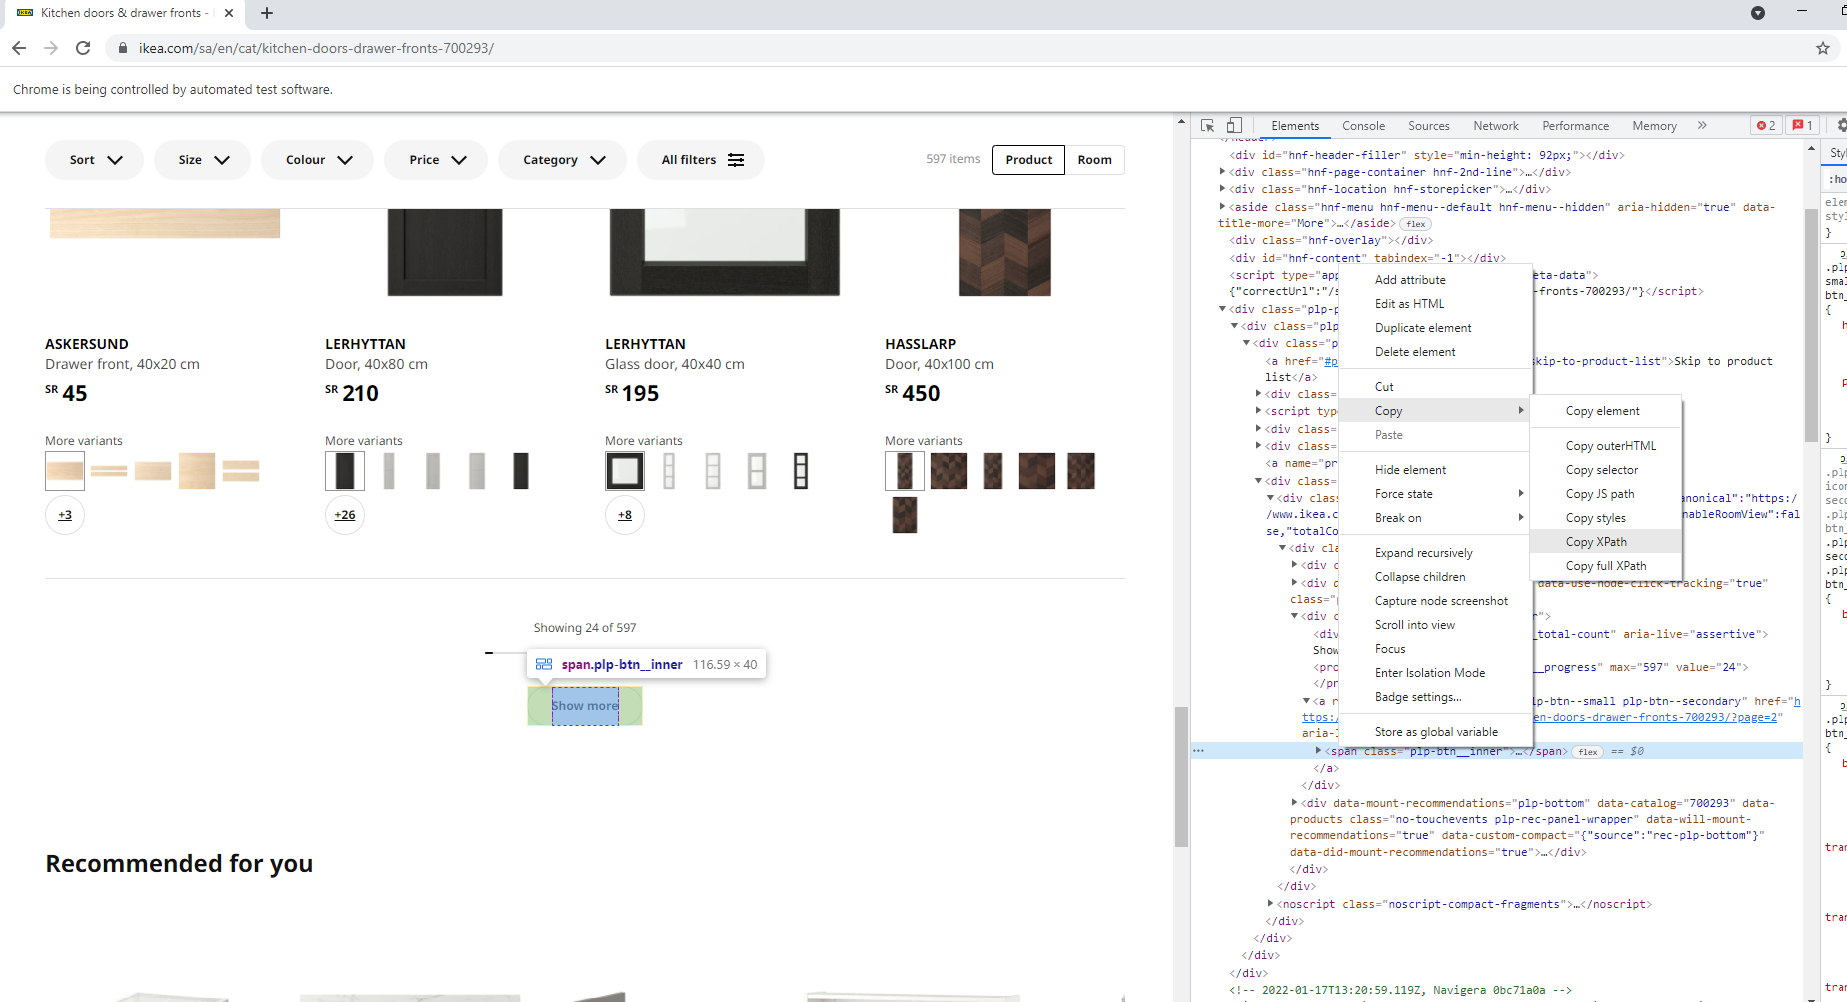

#### 3.3.1 You can use one the following three ways to `click` on the `Next` or `show more` buttons

> a. Locate **`XPath`** of the button then click it

In [73]:
# if you selected "copy XPath", you can use the command  driver.find_element followed by .click()

# Your code here


> b. Locate **`CSS selector`** of the button then click it

In [81]:
# if you selected "copy selector", you can use the command  driver.find_element By.CSS_SELECTOR followed by .click()

# Your code here



> c. Locate **`Link Text`** of the button then click it

In [82]:
# you can use the command By.LINK_TEXT followed by .click() if you know that the next page has a text.
# from our page in this example, we can see that the next page button:
# has a name which is called "Show more".

# Your code here



- #### Then what?
    -  you can refer to the content of the page using driver.page_source
    -  you can use BeautifulSoup to get the page_source to parse your data
    

### 3.4 Method 4: If the next page is in a date format
- You need to go to the next day using the `datetime` library
- For the following link, notice that the link format is a date:

url ="https://www.wunderground.com/history/daily/bh/isa-town/OBBI/date/2023-7-15"

In [83]:
# You need to import the following libraries
from datetime import date
from datetime import timedelta

In [84]:
# assume we want to do the following from 15-7-2023 to 20-7-2023
# notice how the url is written with curely brackets
url="https://www.wunderground.com/history/daily/bh/isa-town/OBBI/date/{}-{}-{}"
start_date=date(2023,7,15)
end_date=date(2023,7,20)

while start_date != end_date:

    f_url = url.format(start_date.year, start_date.month,start_date.day)
    # or:
    # f_url = f"https://www.wunderground.com/history/daily/bh/isa-town/OBBI/date/{start_date.year}-{start_date.month}-{start_date.day}"
    print (f_url)
    start_date = start_date + timedelta(days=1)  # going to next day using timedelta


# then
# driver.get(formatted_lookup_URL) 
# Do the necessary web scraping


https://www.wunderground.com/history/daily/bh/isa-town/OBBI/date/2023-7-15
https://www.wunderground.com/history/daily/bh/isa-town/OBBI/date/2023-7-16
https://www.wunderground.com/history/daily/bh/isa-town/OBBI/date/2023-7-17
https://www.wunderground.com/history/daily/bh/isa-town/OBBI/date/2023-7-18
https://www.wunderground.com/history/daily/bh/isa-town/OBBI/date/2023-7-19



## 4. Using `WebDriverWait()` & `until` function to wait to load a specific object in the web page

---

- Due to the speed of selenium web page switching, you may go to the next page without collecting the info that you need.
- You may need your selenium browser page to wait to a specific object to appear in the web page in order to collect its data.
- One good way to make sure that the web page is completely appear is to use WebDriverWait.
- Let us see this in the next example

### 4.1 Example on using `WebDriverWait()`  & `until`: 
---

#### Let us web scrape from Weather Underground site for Bahrain weather

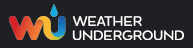



> We are going to web scrape the weather for Bahrain for date 2023-7-15 

https://www.wunderground.com/history/daily/bh/isa-town/OBBI/date/2023-7-15

In [8]:
driver = webdriver.Chrome()
url="https://www.wunderground.com/history/daily/bh/isa-town/OBBI/date/2023-7-15"

driver.get(url)
# wait until the table that has the hourly weather
WebDriverWait(driver, 60).until(EC.visibility_of_all_elements_located((By.XPATH, '//*[@id="inner-content"]/div[2]/div[1]/div[5]/div[1]/div/lib-city-history-observation/div/div[2]/table/tbody')))
soup = BeautifulSoup(driver.page_source,'html.parser')


# Extra tip on reading tables directly:
- We can use pandas `read_html` function which reads table that are in the page and show each table as DataFrame.
- Let's try it on the above weather site

In [161]:
# install lxml library for the first time
# !pip install lxml

In [10]:
# Using pandas to grab all the tables in the html and return each
# as a dataframe

# import StringIO library
from io import StringIO

mytables=pd.read_html(StringIO(driver.page_source))

# with old version, you can use:
# mytables=pd.read_html(driver.page_source)

In [11]:
# check the length of mytables to see how many tables it has
len(mytables)

2

In [135]:
# check which table we want out of the two table
# mytables[0]

In [1]:
# check which table we want out of the two table
# mytables[1]

In [13]:
type(mytables[1])

pandas.core.frame.DataFrame

In [14]:
# Note: there are some null values at the end of the table, not clear
# why they are there. just remove them using dropna()
# notice that the table extracted from html is already a DataFrame
# and that is why we can use all the functions like dropna() on it

weather = mytables[1].dropna()

weather.tail()

,Time,Temperature,Dew Point,Humidity,Wind,Wind Speed,Wind Gust,Pressure,Precip.,Condition
43,9:30 PM,91 °F,86 °F,84 °%,ESE,6 °mph,0 °mph,29.46 °in,0.0 °in,Haze
44,10:00 PM,91 °F,84 °F,79 °%,ESE,7 °mph,0 °mph,29.46 °in,0.0 °in,Haze
45,10:30 PM,91 °F,86 °F,84 °%,ESE,7 °mph,0 °mph,29.46 °in,0.0 °in,Haze
46,11:00 PM,91 °F,84 °F,79 °%,ESE,7 °mph,0 °mph,29.46 °in,0.0 °in,Haze
47,11:30 PM,91 °F,84 °F,79 °%,ESE,6 °mph,0 °mph,29.46 °in,0.0 °in,Haze


#### Save your dataframe to a `CSV` file
- Save the output to a csv file (excluding the index)

In [147]:
# Save the output to a csv file (excluding the index)

weather.to_csv("bahrain_weather.csv",index=False)

### Scraping Tables using Power BI:

- You can scrape a table in any webpage using Power BI as long as the page is static (not a Java script)
- Let's try one link that has a table. Copy the following link:

https://en.wikipedia.org/wiki/List_of_U.S._states_and_territories_by_life_expectancy

- From Power BI, select `Get Data` and then select `Web`
- Paste the above link
- Select the table you want to import it into Power BI

### 4.2 Scraping Weather Underground site without using `pd.read_html`  (Optional)

> We are going to web scrape the weather for Bahrain from date 2023-7-15 to 2023-7-19



In [141]:
# call chrome webdriver to open a new page
driver = webdriver.Chrome()

- you have to import `date` from `datetime` library in order to run the following example 


In [142]:
# you have to import date from datetime library to run the code here
# Use .format(YYYY, M, D)
url="https://www.wunderground.com/history/daily/bh/isa-town/OBBI/date/{}-{}-{}"




In [143]:
# create the lists to save the table content and the date
tdate=[]
time=[]
temperature=[]
dewpoint=[]
humidity=[]
wind=[]
wind_speed=[]
wind_gust=[]
pressure=[]
precip=[]
condition=[]


In [144]:
start_date=date(2023,7,15)
end_date=date(2023,7,20)

while start_date != end_date:
    #print('gathering data from: ', start_date)
    formatted_url = url.format(start_date.year,
                               start_date.month,
                               start_date.day)
    
    driver.get(formatted_url)
    # wait until the table that has the hourly weather
    WebDriverWait(driver, 60).until(EC.visibility_of_all_elements_located((By.XPATH, '//*[@id="inner-content"]/div[2]/div[1]/div[5]/div[1]/div/lib-city-history-observation/div/div[2]/table/tbody')))
    soup = BeautifulSoup(driver.page_source,'html')#'html.parser')
    for i in soup.find_all(class_="mat-row cdk-row ng-star-inserted"):
        tdate.append(start_date)
        time.append(i.find(class_="ng-star-inserted").text)
        temperature.append(i.find(class_="test-true wu-unit wu-unit-temperature is-degree-visible ng-star-inserted").find(class_="wu-value wu-value-to").text)    
        dewpoint.append(i.find(class_="mat-cell cdk-cell cdk-column-dewPoint mat-column-dewPoint ng-star-inserted").find(class_="wu-value wu-value-to").text)
        humidity.append(i.find(class_="test- wu-unit wu-unit-humidity ng-star-inserted").find(class_="wu-value wu-value-to").text)
        wind.append(i.find(class_="mat-cell cdk-cell cdk-column-windcardinal mat-column-windcardinal ng-star-inserted").find(class_="ng-star-inserted").text)
        wind_speed.append(i.find(class_="mat-cell cdk-cell cdk-column-windSpeed mat-column-windSpeed ng-star-inserted").find(class_="wu-value wu-value-to").text)
        wind_gust.append(i.find(class_="mat-cell cdk-cell cdk-column-windGust mat-column-windGust ng-star-inserted").find(class_="wu-value wu-value-to").text)
        pressure.append(i.find(class_="mat-cell cdk-cell cdk-column-pressure mat-column-pressure ng-star-inserted").find(class_="wu-value wu-value-to").text)
        precip.append(i.find(class_="mat-cell cdk-cell cdk-column-precipRate mat-column-precipRate ng-star-inserted").find(class_="wu-value wu-value-to").text)
        condition.append(i.find(class_="mat-cell cdk-cell cdk-column-condition mat-column-condition ng-star-inserted").find(class_="ng-star-inserted").text)  
    start_date += timedelta(days=1)

In [148]:
# create the dataframe
weather2=pd.DataFrame({'date':tdate,
                      'time':time,
                 'temperature':temperature,
                 'dewpoint':dewpoint,
                 'humidity':humidity,
                 'wind':wind,
                 'wind_speed':wind_speed,
                 'wind_gust':wind_gust,
                 'pressure':pressure,
                 'precip':precip,
                 'condition':condition
                
                })

In [149]:
weather2.head()

,date,time,temperature,dewpoint,humidity,wind,wind_speed,wind_gust,pressure,precip,condition
0,2023-07-15,12:00 AM,90,84,84,E,9,0,29.46,0.0,Fog
1,2023-07-15,12:30 AM,90,84,84,E,8,0,29.46,0.0,Fog
2,2023-07-15,1:00 AM,90,84,84,ESE,8,0,29.46,0.0,Fog
3,2023-07-15,1:30 AM,90,84,84,ESE,7,0,29.46,0.0,Fog
4,2023-07-15,2:00 AM,90,84,84,ESE,6,0,29.46,0.0,Fog


In [151]:
len(weather2)

240

#### Save your dataframe to a `CSV` file
- Save the output to a csv file (excluding the index)

In [147]:
# Save the output to a csv file (excluding the index)

weather2.to_csv("bahrain_weather2.csv",index=False)

# Important Hint: 
- You may work with hundreds of pages.It will be a good practice to do the following before closing your labtop in order to save your work:
    1. save the pages that you went through in a list. Before the end of you day, export this list to a csv file. By this, you will know to which page you have reached and continue your web scraping from the point that you have reached.
    2. if you start scraping your data, put them in a dataframe and export that dataframe to a csv file.

<a id='resources'></a>

## Additional resources

---
> [Official Selenium site](https://www.selenium.dev/) 

> [webdriver documentation](https://selenium-python.readthedocs.io/api.html)

> [Locating Elements in a page using Selenium.](https://selenium-python.readthedocs.io/locating-elements.html)

> [Selenium Tips: CSS Selectors](https://saucelabs.com/resources/articles/selenium-tips-css-selectors)

> https://selenium-python.readthedocs.io/index.html

In [57]:
%autosave 0

Autosave disabled
